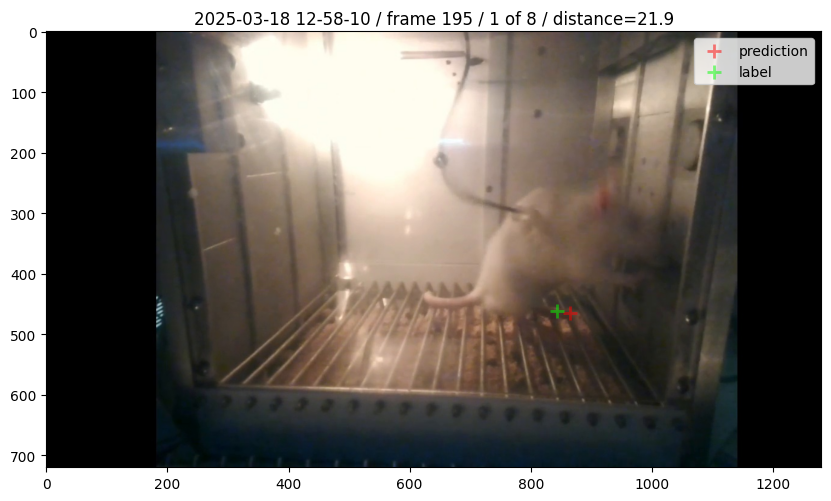

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import clear_output, display
import ipywidgets as widgets
import matplotlib
import matplotlib.pyplot as plt

try:
    import ipympl  # noqa: F401
    if "get_ipython" in globals():
        get_ipython().run_line_magic("matplotlib", "widget")
except Exception:
    pass

HAS_IPYMPL = "ipympl" in matplotlib.get_backend().lower()


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "input").is_dir() and (candidate / "output").is_dir() and (candidate / "modules").is_dir():
            return candidate
    raise FileNotFoundError("Could not find the project root from the current working directory.")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from modules.manual_correction_utils import (
    compute_distance,
    find_flagged_frames,
    get_frame_image_path,
    get_label_point,
    get_latest_prediction_root,
    get_prediction_point,
    get_video_pairs,
    list_keypoints,
    load_prediction_map,
    load_video_labels,
    remove_label_point,
    save_video_labels,
    update_label_point,
)

PREDICTED_FRAMES_ROOT = PROJECT_ROOT / "output" / "predicted_frames"
LABELED_DATA_ROOT = PROJECT_ROOT / "input" / "labeled-data"
LABELED_FRAMES_ROOT = PROJECT_ROOT / "output" / "labeled_frames"


class InteractiveLabelEditor:
    def __init__(self) -> None:
        self.prediction_root = get_latest_prediction_root(PREDICTED_FRAMES_ROOT)
        self.video_names = get_video_pairs(self.prediction_root, LABELED_DATA_ROOT)
        if not self.video_names:
            raise FileNotFoundError("No videos found with both prediction JSON and DLC CSV labels.")

        self.current_video: str | None = None
        self.current_csv_path: Path | None = None
        self.prediction_map: dict[int, dict] = {}
        self.label_df: pd.DataFrame | None = None
        self.filtered_frames: list[int] = []
        self.current_index = 0
        self.dragging = False
        self.drag_frame_idx: int | None = None
        self.suspend_events = False

        self.model_label = widgets.HTML()
        self.video_dropdown = widgets.Dropdown(description="Video:", options=self.video_names, layout=widgets.Layout(width="360px"))
        self.keypoint_dropdown = widgets.Dropdown(description="Keypoint:", options=[], layout=widgets.Layout(width="240px"))
        self.cutoff_widget = widgets.FloatText(description="Cutoff:", value=20.0, step=1.0, layout=widgets.Layout(width="170px"))
        self.prev_button = widgets.Button(description="← Prev", layout=widgets.Layout(width="100px"))
        self.next_button = widgets.Button(description="Next →", layout=widgets.Layout(width="100px"))
        self.status_label = widgets.HTML()
        self.message_label = widgets.HTML()
        self.figure_output = widgets.Output()

        self.fig, self.ax = plt.subplots(figsize=(10, 6))
        self._set_model_label()
        self._bind_events()

        controls_top = widgets.HBox([self.video_dropdown, self.keypoint_dropdown, self.cutoff_widget])
        controls_bottom = widgets.HBox([self.prev_button, self.next_button, self.status_label])
        display(widgets.VBox([self.model_label, controls_top, self.message_label, self.figure_output, controls_bottom]))
        with self.figure_output:
            clear_output(wait=True)
            if HAS_IPYMPL:
                display(self.fig.canvas)
            else:
                display(self.fig)
        try:
            self._load_video(reset_keypoint=True)
        except Exception as exc:
            self._show_error(f"Initialization failed: {exc}")

    def _draw_figure(self) -> None:
        if HAS_IPYMPL:
            self.fig.canvas.draw_idle()
            return
        with self.figure_output:
            clear_output(wait=True)
            display(self.fig)

    def _show_error(self, message: str) -> None:
        self.ax.clear()
        self.ax.set_axis_off()
        self.ax.text(0.5, 0.5, message, ha="center", va="center", wrap=True, transform=self.ax.transAxes)
        self.message_label.value = f"<span style='color: #aa0000;'>{message}</span>"
        self.status_label.value = ""
        self._draw_figure()

    def _set_model_label(self) -> None:
        self.model_label.value = f"<b>Prediction model:</b> {self.prediction_root}"

    def _bind_events(self) -> None:
        self.video_dropdown.observe(self._on_video_change, names="value")
        self.keypoint_dropdown.observe(self._on_keypoint_change, names="value")
        self.cutoff_widget.observe(self._on_cutoff_change, names="value")
        self.prev_button.on_click(lambda _: self._step_frame(-1))
        self.next_button.on_click(lambda _: self._step_frame(1))
        self.fig.canvas.mpl_connect("button_press_event", self._on_mouse_press)
        self.fig.canvas.mpl_connect("button_release_event", self._on_mouse_release)
        self.fig.canvas.mpl_connect("motion_notify_event", self._on_mouse_move)
        self.fig.canvas.mpl_connect("key_press_event", self._on_key_press)
        self.fig.canvas.mpl_connect("scroll_event", self._on_scroll)

    def _on_video_change(self, change) -> None:
        if self.suspend_events or change.get("new") == change.get("old"):
            return
        try:
            self._load_video(reset_keypoint=True)
        except Exception as exc:
            self._show_error(f"Video load failed: {exc}")

    def _on_keypoint_change(self, change) -> None:
        if self.suspend_events or change.get("new") == change.get("old"):
            return
        try:
            self._refresh_filtered_frames(reset_index=True)
        except Exception as exc:
            self._show_error(f"Keypoint refresh failed: {exc}")

    def _on_cutoff_change(self, change) -> None:
        if self.suspend_events or change.get("new") == change.get("old"):
            return
        try:
            self._refresh_filtered_frames(reset_index=True)
        except Exception as exc:
            self._show_error(f"Cutoff refresh failed: {exc}")

    def _load_video(self, reset_keypoint: bool) -> None:
        video_name = self.video_dropdown.value
        if not video_name:
            return

        self.current_video = str(video_name)
        self.current_csv_path = LABELED_DATA_ROOT / self.current_video / "CollectedData_rats.csv"
        prediction_json_path = self.prediction_root / f"{self.current_video}.json"
        self.prediction_map = load_prediction_map(prediction_json_path)
        self.label_df = load_video_labels(self.current_csv_path)

        keypoints = list_keypoints(self.prediction_map, self.label_df)
        self.suspend_events = True
        self.keypoint_dropdown.options = keypoints
        if keypoints:
            if reset_keypoint or self.keypoint_dropdown.value not in keypoints:
                self.keypoint_dropdown.value = keypoints[0]
        else:
            self.keypoint_dropdown.value = None
        self.suspend_events = False
        self._refresh_filtered_frames(reset_index=True)

    def _refresh_filtered_frames(self, reset_index: bool, preferred_frame: int | None = None) -> None:
        if self.label_df is None or not self.keypoint_dropdown.value:
            self.filtered_frames = []
            self.current_index = 0
            self._render()
            return

        old_frame = preferred_frame if preferred_frame is not None else self.current_frame_idx
        self.filtered_frames = find_flagged_frames(
            self.prediction_map,
            self.label_df,
            str(self.keypoint_dropdown.value),
            float(self.cutoff_widget.value),
        )

        if not self.filtered_frames:
            self.current_index = 0
        elif reset_index or old_frame is None:
            self.current_index = 0
        elif old_frame in self.filtered_frames:
            self.current_index = self.filtered_frames.index(old_frame)
        else:
            insert_at = np.searchsorted(self.filtered_frames, old_frame)
            self.current_index = min(int(insert_at), len(self.filtered_frames) - 1)

        self._render()

    @property
    def current_frame_idx(self) -> int | None:
        if not self.filtered_frames:
            return None
        if self.current_index < 0 or self.current_index >= len(self.filtered_frames):
            return None
        return int(self.filtered_frames[self.current_index])

    def _step_frame(self, step: int) -> None:
        if not self.filtered_frames:
            return
        self.current_index = int(np.clip(self.current_index + step, 0, len(self.filtered_frames) - 1))
        try:
            self._render()
        except Exception as exc:
            self._show_error(f"Navigation failed: {exc}")

    def _save_current_labels(self) -> None:
        if self.label_df is None or self.current_video is None or self.current_csv_path is None:
            return
        save_video_labels(self.label_df, self.current_video, self.current_csv_path)

    def _render(self) -> None:
        self.ax.clear()
        self.dragging = False
        self.drag_frame_idx = None

        if self.current_video is None or not self.keypoint_dropdown.value:
            self.status_label.value = ""
            self.message_label.value = "<span style='color: #aa0000;'>No video or keypoint selected.</span>"
            self.ax.set_axis_off()
            self.ax.text(0.5, 0.5, "No video or keypoint selected.", ha="center", va="center", transform=self.ax.transAxes)
            self._draw_figure()
            return

        if not self.filtered_frames:
            self.status_label.value = "0 / 0"
            self.message_label.value = "<span style='color: #0a5;'>No frames exceed the cutoff.</span>"
            self.ax.set_axis_off()
            self.ax.text(0.5, 0.5, "No frames exceed the cutoff.", ha="center", va="center", transform=self.ax.transAxes)
            self._draw_figure()
            return

        frame_idx = self.current_frame_idx
        image_path = get_frame_image_path(LABELED_FRAMES_ROOT, self.current_video, frame_idx)
        if not image_path.is_file():
            self.status_label.value = f"{self.current_index + 1} / {len(self.filtered_frames)}"
            self.message_label.value = f"<span style='color: #aa0000;'>Missing frame image: {image_path}</span>"
            self.ax.set_axis_off()
            self.ax.text(0.5, 0.5, f"Missing frame image\n{image_path.name}", ha="center", va="center", transform=self.ax.transAxes)
            self._draw_figure()
            return

        image = plt.imread(image_path)
        self.ax.imshow(image)
        self.ax.set_axis_on()

        keypoint = str(self.keypoint_dropdown.value)
        prediction_point = get_prediction_point(self.prediction_map, frame_idx, keypoint)
        label_point = get_label_point(self.label_df, frame_idx, keypoint) if self.label_df is not None else None

        if prediction_point is not None:
            self.ax.scatter(prediction_point[0], prediction_point[1], c="red", s=110, marker="+", alpha=0.5, linewidths=2.0, label="prediction")
        if label_point is not None:
            self.ax.scatter(label_point[0], label_point[1], c="lime", s=110, marker="+", alpha=0.5, linewidths=2.0, label="label")

        if prediction_point is not None or label_point is not None:
            self.ax.legend(loc="upper right")

        distance = compute_distance(self.prediction_map, self.label_df, frame_idx, keypoint) if self.label_df is not None else None
        distance_text = "n/a" if distance is None else f"{distance:.1f}"
        self.ax.set_title(f"{self.current_video} / frame {frame_idx} / {self.current_index + 1} of {len(self.filtered_frames)} / distance={distance_text}")
        self.status_label.value = f"<b>{self.current_index + 1} / {len(self.filtered_frames)}</b>"
        self.message_label.value = "Use left-drag to move the green label, right-click to remove it, a/d to switch frames, arrow keys to nudge by 1 px."
        self._draw_figure()

    def _save_and_refresh_after_edit(self, frame_idx: int) -> None:
        self._save_current_labels()
        self._refresh_filtered_frames(reset_index=False, preferred_frame=frame_idx)

    def _on_mouse_press(self, event) -> None:
        if event.inaxes != self.ax or self.current_frame_idx is None or self.label_df is None:
            return

        keypoint = str(self.keypoint_dropdown.value)
        frame_idx = self.current_frame_idx
        label_point = get_label_point(self.label_df, frame_idx, keypoint)

        if event.button == 3:
            if label_point is None:
                return
            remove_label_point(self.label_df, frame_idx, keypoint)
            self._save_and_refresh_after_edit(frame_idx)
            return

        if event.button != 1 or label_point is None or event.xdata is None or event.ydata is None:
            return

        dx = float(event.xdata) - label_point[0]
        dy = float(event.ydata) - label_point[1]
        if np.hypot(dx, dy) <= 20:
            self.dragging = True
            self.drag_frame_idx = frame_idx

    def _on_mouse_move(self, event) -> None:
        if not self.dragging or event.inaxes != self.ax or event.xdata is None or event.ydata is None:
            return
        self.ax.set_title(f"Dragging to ({event.xdata:.1f}, {event.ydata:.1f})")
        self._draw_figure()

    def _on_mouse_release(self, event) -> None:
        if not self.dragging:
            return
        self.dragging = False
        frame_idx = self.drag_frame_idx
        self.drag_frame_idx = None
        if frame_idx is None or self.label_df is None or event.inaxes != self.ax or event.xdata is None or event.ydata is None:
            self._render()
            return
        update_label_point(self.label_df, frame_idx, str(self.keypoint_dropdown.value), float(event.xdata), float(event.ydata))
        self._save_and_refresh_after_edit(frame_idx)

    def _on_scroll(self, event) -> None:
        if event.inaxes != self.ax or event.xdata is None or event.ydata is None:
            return

        scale_factor = 0.9 if event.button == "up" else 1.1
        x_min, x_max = self.ax.get_xlim()
        y_min, y_max = self.ax.get_ylim()

        if x_max == x_min or y_max == y_min:
            return

        new_width = (x_max - x_min) * scale_factor
        new_height = (y_max - y_min) * scale_factor
        x_ratio = (event.xdata - x_min) / (x_max - x_min)
        y_ratio = (event.ydata - y_min) / (y_max - y_min)

        new_x_min = event.xdata - new_width * x_ratio
        new_x_max = event.xdata + new_width * (1 - x_ratio)
        new_y_min = event.ydata - new_height * y_ratio
        new_y_max = event.ydata + new_height * (1 - y_ratio)

        self.ax.set_xlim(new_x_min, new_x_max)
        self.ax.set_ylim(new_y_min, new_y_max)
        self._draw_figure()

    def _on_key_press(self, event) -> None:
        frame_idx = self.current_frame_idx
        if frame_idx is None or self.label_df is None:
            return

        if event.key == "a":
            self._step_frame(-1)
            return
        if event.key == "d":
            self._step_frame(1)
            return

        keypoint = str(self.keypoint_dropdown.value)
        label_point = get_label_point(self.label_df, frame_idx, keypoint)
        if label_point is None:
            return

        dx = 0
        dy = 0
        if event.key == "left":
            dx = -1
        elif event.key == "right":
            dx = 1
        elif event.key == "up":
            dy = -1
        elif event.key == "down":
            dy = 1
        else:
            return

        update_label_point(self.label_df, frame_idx, keypoint, label_point[0] + dx, label_point[1] + dy)
        self._save_and_refresh_after_edit(frame_idx)


editor = InteractiveLabelEditor()
